In [6]:
#libraries used
import pandas as pd
import numpy as np

#Visuals for the plot
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing using various methods
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Models used
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

#Warnings
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colabfiles/Credit_Card.csv",
    sep=None,
    engine="python")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   347

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709
dtype: int64


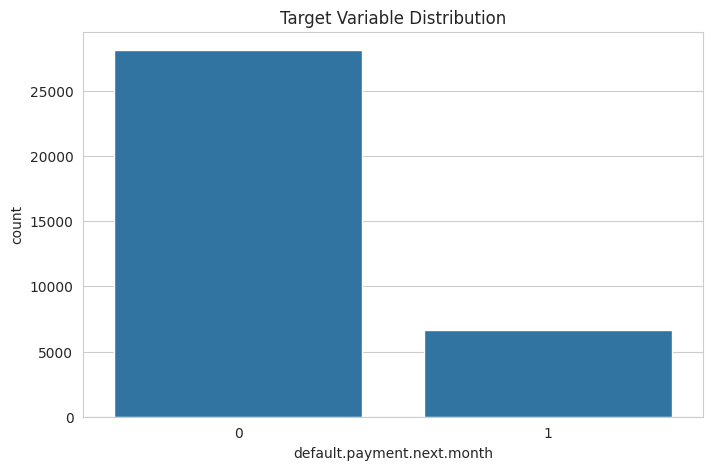

default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='default.payment.next.month', data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df['default.payment.next.month'].value_counts(normalize=True)*100)

In [12]:
features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']

df[features].describe()

,LIMIT_BAL,AGE,BILL_AMT_SUM
count,3.307900e+04,33033.000000,3.478800e+04
mean,1.846690e+05,35.518300,2.948152e+05
std,2.359319e+05,9.236783,5.718073e+05
min,1.000000e+04,21.000000,-3.362590e+05
25%,6.000000e+04,28.000000,2.973825e+04
50%,1.400000e+05,34.000000,1.290370e+05
75%,2.400000e+05,41.000000,3.502095e+05
max,5.600000e+06,79.000000,2.129266e+07


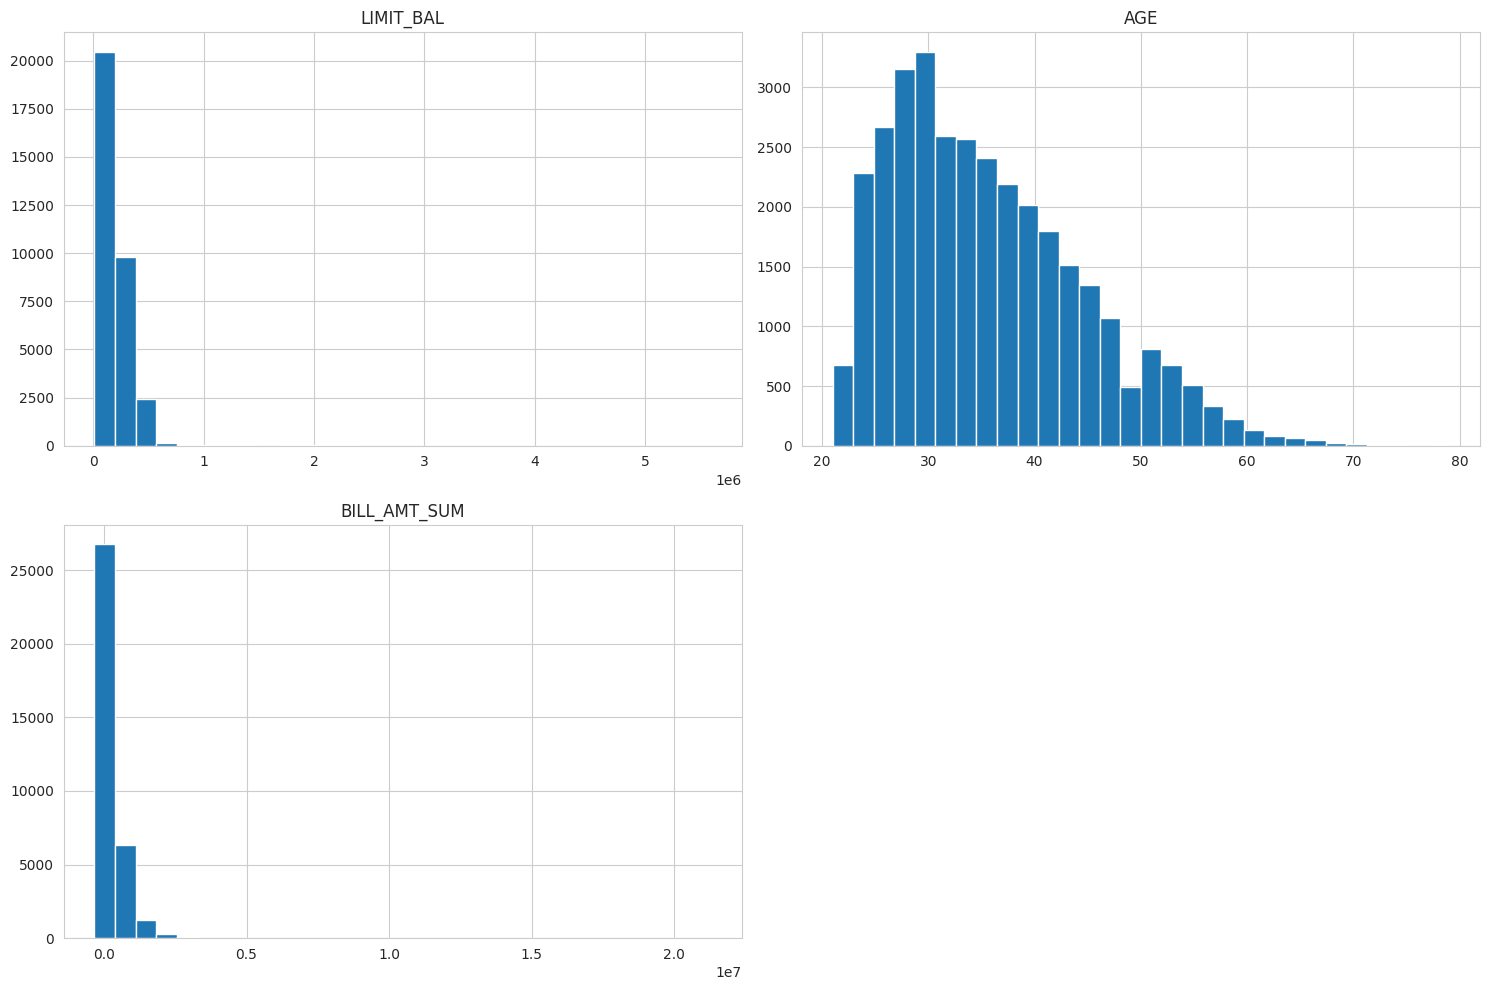

In [13]:
df[features].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

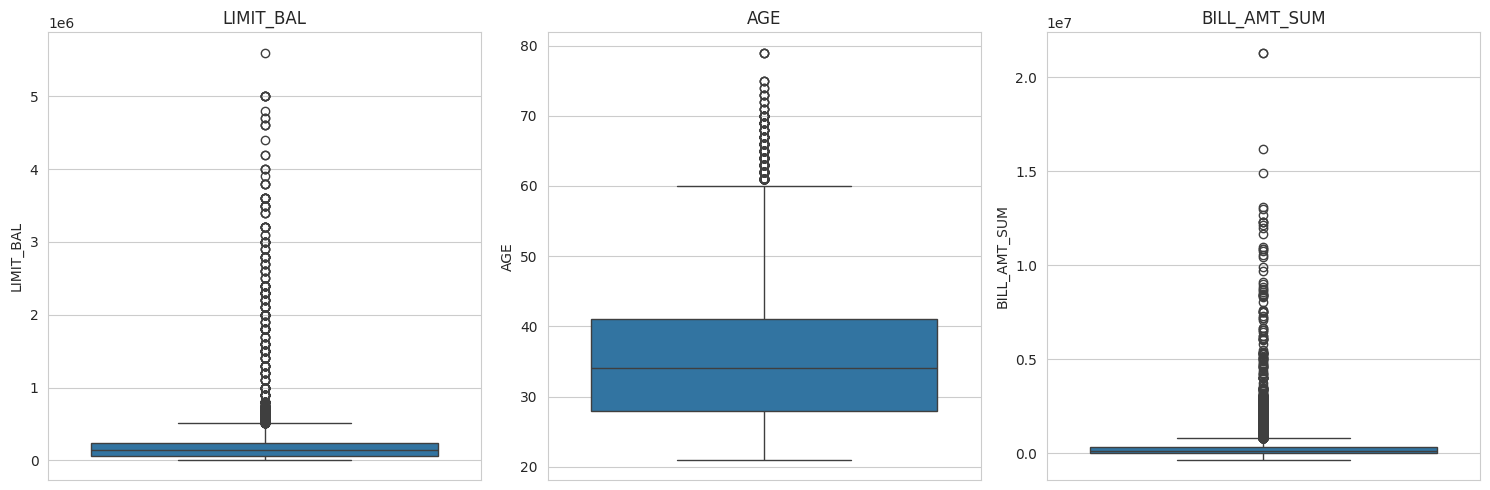

In [30]:
#Boxplot to detect outliers

outlier_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]

plt.figure(figsize=(15,5))

for i, col in enumerate(outlier_features, 1):
    plt.subplot(1, len(outlier_features), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
#IQR method for outlier detection

for col in outlier_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Number of Outliers: {len(outliers)}")


LIMIT_BAL
Number of Outliers: 475

AGE
Number of Outliers: 312

BILL_AMT_SUM
Number of Outliers: 3061


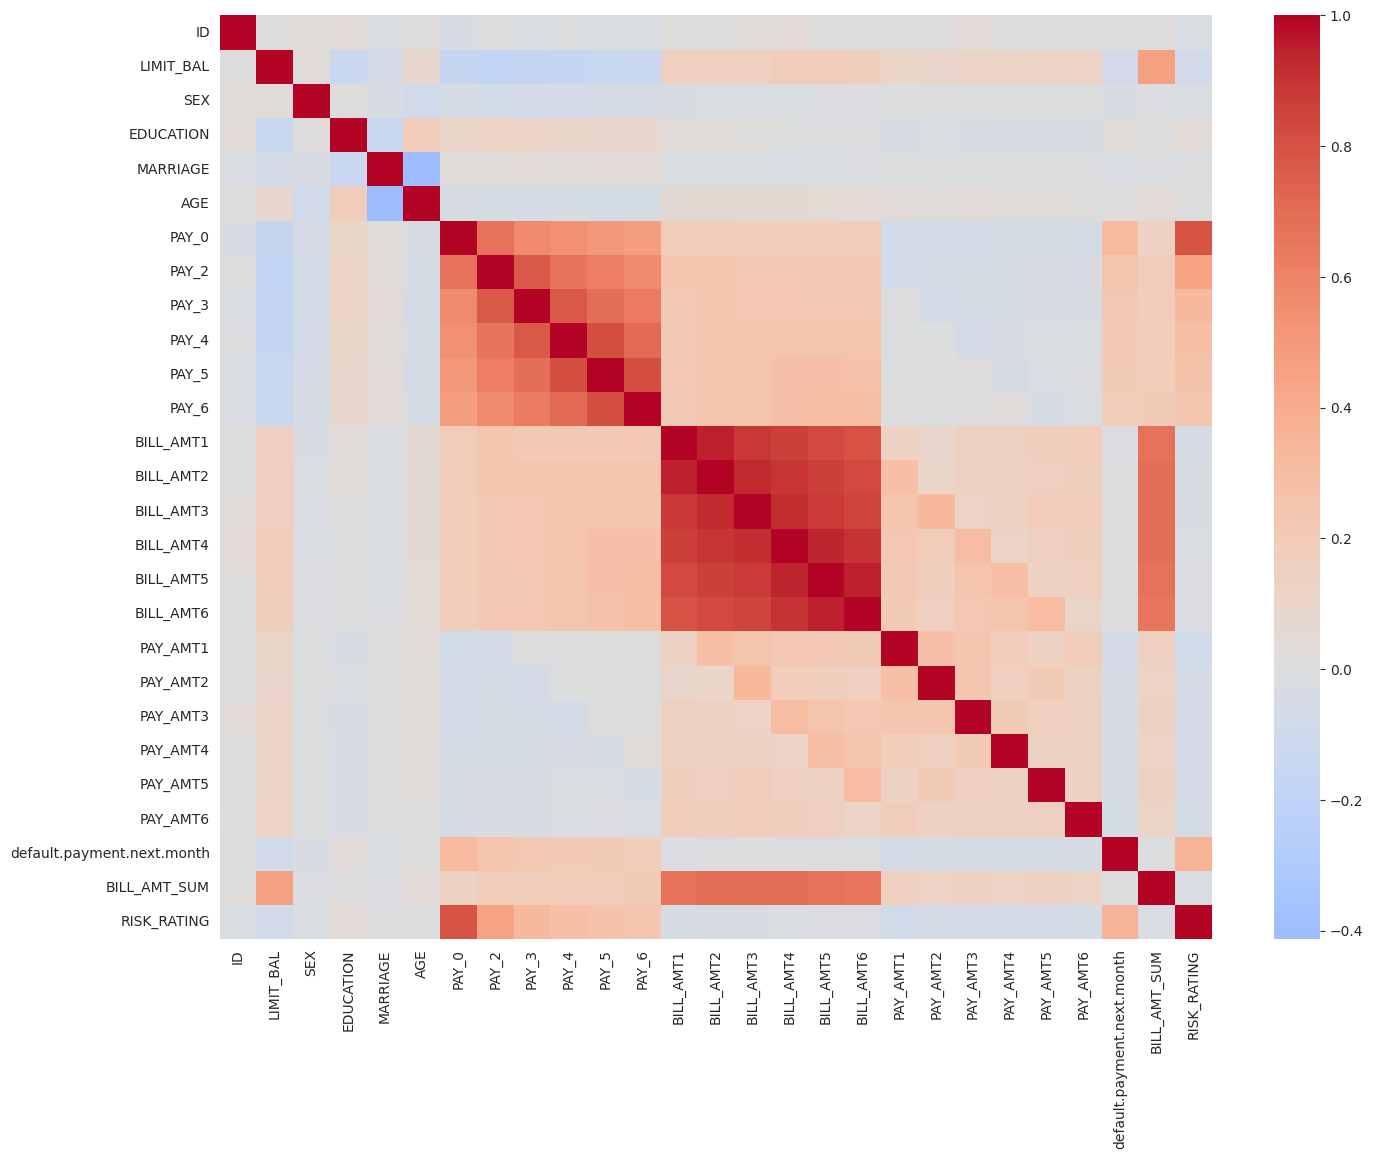

In [15]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)
plt.show()

In [16]:
#Separating target
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

#Removing identifier column
if 'ID' in X.columns:
    X = X.drop('ID', axis=1)

#Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

#Imputer & scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols)
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(27830, 28) (6958, 28)


In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [19]:
results = []

for name, model in models.items():
  pipeline = Pipeline(
      [
          ('preprocessor', preprocessor),
          ('classifier', model)
      ]
  )

  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)
  y_prob = pipeline.predict_proba(X_test)[:,1]

  results.append({
      'Model': name,
      'Accuracy': accuracy_score(y_test, y_pred),
      'Precision': precision_score(y_test, y_pred),
      'Recall': recall_score(y_test, y_pred),
      'F1 Score': f1_score(y_test, y_pred),
      'AUC-ROC': roc_auc_score(y_test, y_prob)
  })

results_df = pd.DataFrame(results)
results_df.sort_values(by='AUC-ROC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
3,Random Forest,0.858149,0.817343,0.332832,0.473038,0.869237
0,Logistic Regression,0.821644,0.588583,0.224643,0.325177,0.746595
1,SVM,0.839034,0.666142,0.317806,0.430315,0.728186
4,KNN,0.828686,0.600579,0.311796,0.410485,0.725885
2,Decision Tree,0.834866,0.602018,0.403456,0.483131,0.670353


In [20]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.821644,0.588583,0.224643,0.325177,0.746595
1,SVM,0.839034,0.666142,0.317806,0.430315,0.728186
2,Decision Tree,0.834866,0.602018,0.403456,0.483131,0.670353
3,Random Forest,0.858149,0.817343,0.332832,0.473038,0.869237
4,KNN,0.828686,0.600579,0.311796,0.410485,0.725885


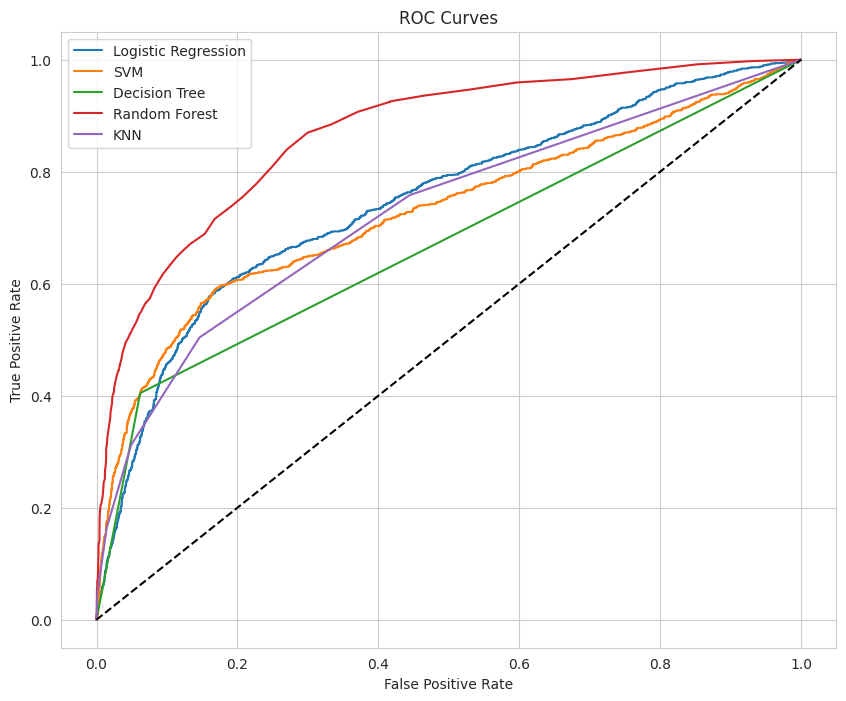

In [21]:
from os import pipe
plt.figure(figsize=(10,8))

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

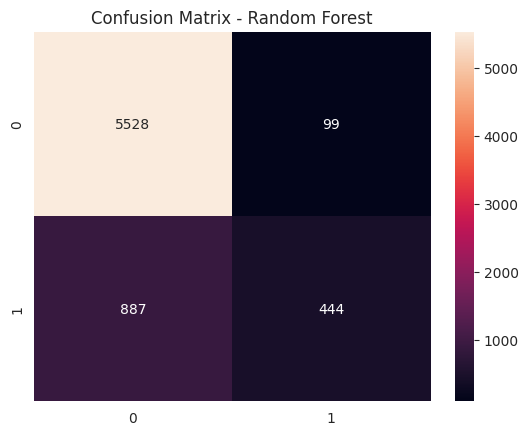

In [22]:
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [23]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__max_depth': 10, 'classifier__n_estimators': 200}
0.7783823730355174


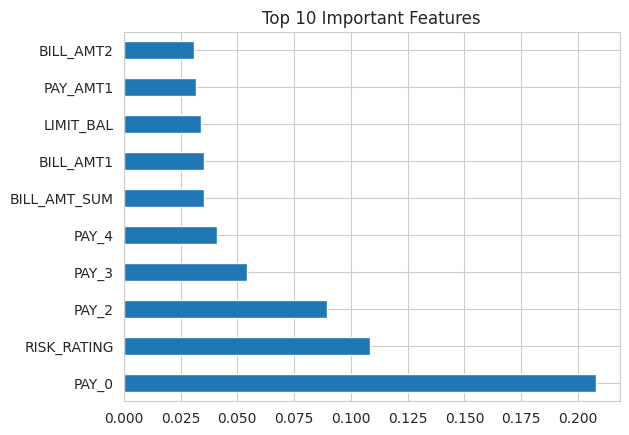

In [24]:
best_rf = grid_search.best_estimator_

feature_names = num_cols

importances = best_rf.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [25]:
!pip install shap -q

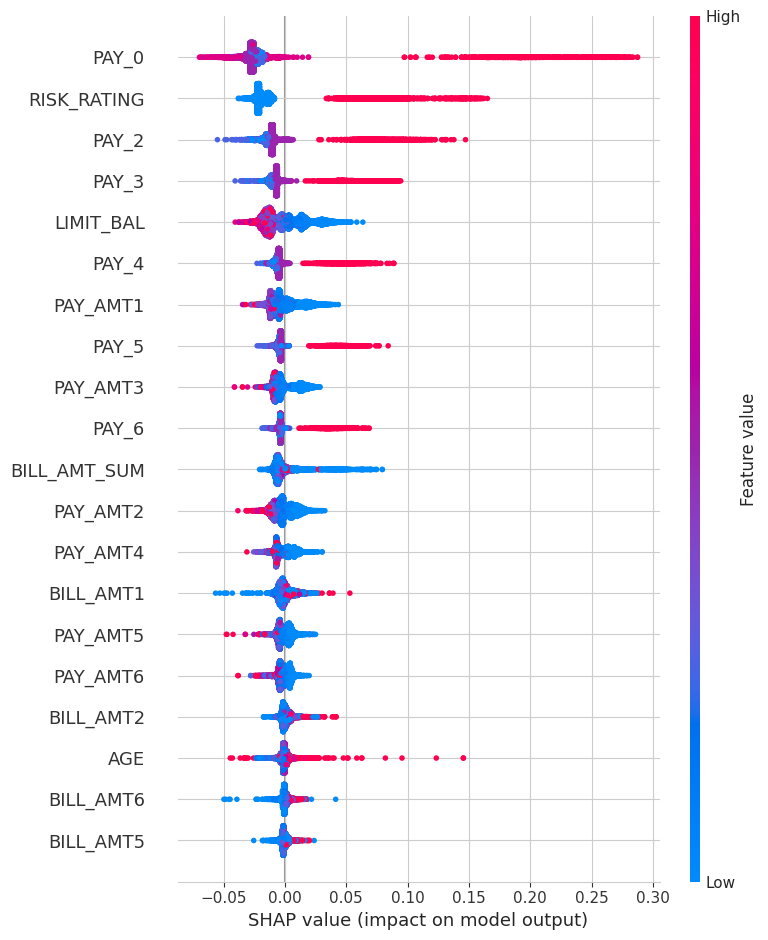

In [29]:
import shap

best_rf = grid_search.best_estimator_

X_test_processed = best_rf.named_steps[
    'preprocessor'
].transform(X_test)

explainer = shap.TreeExplainer(
    best_rf.named_steps['classifier']
)

shap_values = explainer.shap_values(
    X_test_processed
)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=num_cols
)